Förord:
Jag kommer i denna del försöka ge mig på att förutsäga en akties pris/spann i framtiden. Jag siktar till att börja med på 7 dagar framåt i tiden som sedan kan utökas till längre tidshorizonter. Jag har börjat göra en del efterforskningar på området och det ligger i sakens natur att prediktionerna blir mer osäkra ju längre tidsspann du försöker förutsäga.
Men, en tanke som jag då har är att ge en användare möjliget att välja 7 dagar, 1 månad, 3 månader och 1 år framåt. Den sista kommer vara oerhört svår att pricka rätt. Men, om man då presenterar ett "confidence"-score tillsammans med predektionen så är tanken att användaren ska se hur säker bedömningen är. 
Datat som jag tänker använda mig av är analytikers rekommendationer. Det verkar finnas sådana dataset som man kan använda sig av för att träna modeller på. Men det kommer jag att märka här i min analys vilken data och vilka features som jag kan använda mig av. 

Jag kommer att sikta på en första version av denna då ämnet kan bli hur djupt som helst, så en 7 dagars predektion med ett backend API som sköter själva träningen(1ggr/vecka/månad) och predektionerna givet en aktie från en front-end. Här tänkte jag ge mig på att skapa en Android-app som frågar efter predektionen på en given aktie.


Analys:
Jag har nu grävt lite i ett dataset med aktier från yfinance här nedan och använt mig av regressionsmodeller för att träna på 1 års historisk data. Det verkar dock som om denna källa till information inte alltid innehåller tillräckligt med information. En annan källa är FinnHub där jag skapat ett
konto och som innehåller betydligt mer data med högre kvalite. Jag noterar här just nu utan att egentligen ännu grävt jättedjupt ännu. Så, mer om detta senare.

Det jag nu vill notera ner är de features/kolumner som blir nödvändiga att ha med vid träning och för att sedan kunna predikera en akties pris, eller rättare sagt så siktar jag på ett spann. Det är inte realistiskt att exakt pricka rätt i pris utan mer visa riktningen och en uppskattad uppgång eller nedgång. 
Antag t ex Eriksson idag har ett pris på 100 kr. Om 7 dagar så ligger priset på mellan 105-110 kr baserat på analytikers rekommendationer, sentiment och historisk data. Eftersom detta är ett relativt kort perspektiv så ligger fokus mest på momentum, volym och volatilitet i detta läge utläst och beräknat från historisk data.

I nästa steg när jag lägger till fler tidshorisonter som 30, 60, 90, 365 dagar så kommer fokus att skifta mer mot fundamentala data, sentiment, analyser, triggers, bolagsrapporter etc.

Men, nu ligger focus på 7 dagars prediktion och då landar vi i några features som blir aktuella i det korta perspektivet. Jag tänker att jag redogör för vilka features jag använder och varför. 

ret_1d, ret_3d, reg_7d - Dessa features handlar om vilket momentum en aktie har och dessa features innehåller hur mycket priset på en aktie har förändrats mellan olika tidsintervall dag 1, dag 3 och dag 7. Modellen som vi nyttjar tränas alltså på att se hur mycket momentum och vilket håll (ner eller upp) en aktie rör sig. Det har också visat sig, ur ett kort perspektiv att en aktie som gått upp fortsätter att gå upp och vice versa. 

Exempel: ret_1d = price.pct_change(1) - Hur mycket har priset förändrats sedan igår?
Dag 1 var priset 100 kr
Dag 2 var priset 105 kr
ret_1d = (105 - 100) / 100 = 0.05 = +5% - Samma som att använda pct_change(1)


vol_7d, vol_14d - Beskriver volatiliteten i en aktie. Alltså hur mycket priset svänger. Liten svängning = låg volatilitet och hög svängning = hög volatilitet. Detta avgör också hur stort spann man kan tänka sig att en aktie rör sig inom och därmed kommer prediktionens spann också att variera beroende på volatiliteten.

Exempel: vol_7d = ticker_returns.rolling(7).std() - Hur mycket en aktie rört sig de senaste 7 dagarna. En stabil aktie med låg vola skulle kunna ha följande utveckling/rörelse de senaste 7 dagarna. +1%, -0.5%, +0.8%, -0.7%, +1%, +0.5%, -0.3%. Medans en aktie med hög vola och större osäkerhet skulle kunna se ut på följande sätt med större svängningar. +5%, -6%, +4%, -7%, +3%, -5%, +6%

Nu funderar man kanske på varför vi även har vol_14d och anledningen är att man vill basera analysen på fler än en signal i detta läge för att mer säkert avgöra volatiliteten. Om aktiens pris svänger kraftigt både på 7 dagar och 14 dagars sikt så innebär det ju en stor osäkerhet om aktiens pris. Vidare bygger vi upp ett spann och dessa båda värden har betydelse för vårt botten och vårt tak i spannet. 

ma_5, ma_10 - Beskriver trenden för en aktie över 5 och 10 dagar. Dvs. ma_5 innehåller ett sk. glidande medelvärde, ett medelvärde för aktiens pris de senaste 5 dagarna. ma_5 den kortare trenden medans ma_10 fångar en liten längre trend.

Exempelvis: 
ma_5 = prices.rolling(5).mean().iloc[-1] - Returnerar medelvärdet för en aktie över 5 dagar. 
Dvs. (100 + 102 + 101 + 103 + 104) / 5 = 102 -> ma_5

ma_5 och ma_10 används dock inte direkt som features i modellen utan vi har en kombination av pris och ma. Dvs price_vs_ma5 och price_vs_ma10 för att beskriva en upptrend eller en nedåtgående trend, normaliserad eftersom modeller har svårt att tolka ett stängningspris rakt av, vi behöver något där vi kan fånga trenden. Rent uttryckt, hur ligger dagens pris i förhållande till priset för 5/10 dagar sedan. 

Exempel: 
Stängningspris (Close) = 110
ma_5 = 102
-> Close / ma_5 -> 110 / 102 = 1.08 -> Pris ligger över sin trend - Bullish

Stängningspris (Close) = 100
ma_5 = 102
-> Close / ma_5 -> 100 / 102 = 0.98 -> Pris ligger under sin trend - Bearish

En sammanställning av de features som används och hur de arbetar tillsammans för 
en prediktion.

ret_* - Momentum
vol_* - Osäkerhet
price_vs_ma5 - trendposition



**Notering om databegränsningar**

yfinance har begränsad analytikerdata för svenska aktier (vissa kan vara tomma)
För verkliga analytikerrekommendationer och sentiment, överväg:

Finnhub API (dyrt!!): detaljerade analytikerrekommendationer och nyhetssentiment
Alpha Vantage: tekniska indikatorer
Investing.com: web scraping (komplicerat men omfattande)
Manuellt kuraterad data: din egen databas med analytikerrapporter

För tillfället använder vi de funktioner vi kan hämta från yfinance och kombinerar dem med egenutvecklade (engineered) features.

I min EDA så fungerar yfinance tillräckligt bra för att kunna göra prediktioner 7 dagar framåt. Det har kommit att visa sig att i min större lösning som baserar sig bl a på en Azure funktion för att läsa in data från yfinance (varje natt) att vi får fel som Error code: 429, en sk. rate limiting och beror på att API:et som jag anropar tolkar min förfrågan som en robot eller liknande. Jag har provat att lägga in timer för att anropa tjänsten med fördröjning på både 2 och 5 sek. Men, detta räcker inte. Lite kort om tid att fortsätta felsöka detta beteende just nu inför presentationen. Med det sagt så finns det en work around just nu som gör att jag kan manuellt träna en modell och lägga upp den som mitt eget api använder för att predikera en akties pris 7 dagar framåt.
Vidare kommer jag antaglien att gå över till något annat API framgent då jag även undersökt hur pålitligt yfinance är. Har bl a kikat på FinnHub men detta är en amerikansk tjänst som kostar väldigt mycket pengar för att kunna få något vettigt från. 
Så, det finns andra t ex Alpha Vantage som blir nästa att kika lite närmare på. Ett annat alternativ skulle kunna vara att bygga en egen tjänst som samlar in aktiepriser mm. Men det ligger lägre fram. 

Jag kikade lite mer på korrelationerna mellan mina features och det visar sig att flera av mina features hänger starkt ihop med varandra, särskilt avkastningsmåtten och pris relativt glidande medelvärden. Det betyder att vissa features beskriver liknande mönster i datan.
Samtidigt ser vi att sambandet med target_return är väldigt svagt för samtliga features. Det tyder på att problemet är svårt, att datan innehåller mycket brus och att modellen sannolikt behöver fler eller bättre features för att prestera bättre.


In [39]:
def compute_features(symbol_id, window_prices, window_returns):
    
    recent_price = window_prices.iloc[-1]

    ma5 = window_prices.rolling(5).mean().iloc[-1]
    ma10 = window_prices.rolling(10).mean().iloc[-1]

    return {
        "symbol_id": symbol_id,
        "recent_price": recent_price,
        "ret_1d": window_returns.iloc[-1],
        "ret_3d": window_prices.pct_change(3).iloc[-1],
        "ret_7d": window_prices.pct_change(7).iloc[-1],
        "vol_7d": window_returns.rolling(7).std().iloc[-1],
        "vol_14d": window_returns.rolling(14).std().iloc[-1],
        "price_vs_ma5": recent_price / ma5,
        "price_vs_ma10": recent_price / ma10,
    }

def predict_ticker(symbol, feats_real, model, features, confidence_level=0.9):
    
    row = feats_real[feats_real["symbol"] == symbol]
    X_one = row[features]
    
    y_pred, y_interval = model.predict_interval(X_one)
    
    r = row["recent_price"].values[0]
    
    return {
        "symbol": symbol,
        "confidence": confidence_level,
        "current_price": r,
        "predicted_price": r * (1 + y_pred[0]),
        "lower_bound": r * (1 + y_interval[0,0,0]),
        "upper_bound": r * (1 + y_interval[0,1,0])
    }


In [40]:
# Loading historical data for OMX30 tickers using yfinance

import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

#read csv file
df = pd.read_csv('omx30_yfinance.csv')

tickers = df['ticker'].tolist()
print(tickers)      


# Get historical data for OMX30 tickers
end_date = datetime.now()
start_date = end_date - timedelta(days=365)  # 1 year of data         

print(f"Downloading historical data from {start_date.date()} to {end_date.date()}")

# Download historical data (closing price) for the specified tickers and date range, source of truth.
hist_data = yf.download(tickers, start=start_date, end=end_date)['Close']

print("Data download complete.")

print(hist_data.info())

print("Columns in historic data:")
print(hist_data.columns)

print(f"Downloaded data shape: {hist_data.shape}")
print(hist_data.head())


['ABB.ST', 'ALFA.ST', 'ASSA-B.ST', 'ATCO-A.ST', 'AZN.ST', 'ERIC-B.ST', 'EPI-A.ST', 'ESSITY-B.ST', 'EQT.ST', 'HEXA-B.ST', 'HM-B.ST', 'INVE-B.ST', 'NDA-SE.ST', 'SAND.ST', 'SEB-A.ST', 'SHB-A.ST', 'SKA-B.ST', 'SKF-B.ST', 'SWED-A.ST', 'TEL2-B.ST', 'TELIA.ST', 'VOLV-B.ST', 'BOL.ST', 'SAAB-B.ST', 'ADDT-B.ST', 'INDU-C.ST', 'NIBE-B.ST', 'EVO.ST', 'LIFCO-B.ST', 'SCA-B.ST']


[*********************100%***********************]  30 of 30 completed

Data download complete.
<class 'pandas.DataFrame'>
DatetimeIndex: 248 entries, 2025-05-15 to 2026-05-13
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ABB.ST       248 non-null    float64
 1   ADDT-B.ST    248 non-null    float64
 2   ALFA.ST      248 non-null    float64
 3   ASSA-B.ST    248 non-null    float64
 4   ATCO-A.ST    248 non-null    float64
 5   AZN.ST       248 non-null    float64
 6   BOL.ST       248 non-null    float64
 7   EPI-A.ST     248 non-null    float64
 8   EQT.ST       248 non-null    float64
 9   ERIC-B.ST    248 non-null    float64
 10  ESSITY-B.ST  248 non-null    float64
 11  EVO.ST       248 non-null    float64
 12  HEXA-B.ST    248 non-null    float64
 13  HM-B.ST      248 non-null    float64
 14  INDU-C.ST    248 non-null    float64
 15  INVE-B.ST    248 non-null    float64
 16  LIFCO-B.ST   248 non-null    float64
 17  NDA-SE.ST    248 non-null    float64
 18  NIBE-B.ST    248 n

In [41]:
# Create features per ticker

import yfinance as yf
import pandas as pd

# Calculate returns (daily percentage change)
returns = hist_data.pct_change()

#print(f"Returns:\n{returns.head()}")

# Create features per ticker
ticker_features = []

tickers = sorted(tickers)  # important: stable order
symbol_map = {ticker: i for i, ticker in enumerate(tickers)}

for ticker in tickers:
            
    if ticker in hist_data.columns:
      
        prices = hist_data[ticker].dropna() #Closing prices for a ticker
        
        #print(f"What type is prices? {type(prices)}")
        
        ticker_returns = returns[ticker].dropna()
        
        print(f"Processing {ticker}: {len(prices)} rows")
        
        # We require at least 15 rows of history/closing prices to compute our features
        if len(prices) < 15:
            print(f"⚠️ Skipping {ticker}: Not enough data")
            continue
        
        # -----------------------------
        # ✅ Latest price
        # -----------------------------
        recent_price = prices.iloc[-1]
        
        
        features = compute_features(symbol_map[ticker], prices, ticker_returns)
        
        ticker_features.append({
            "symbol": ticker,
            **features
        })        
        

feats_real = pd.DataFrame(ticker_features)
print("\nReal historical features:")
print(feats_real)

Processing ABB.ST: 248 rows
Processing ADDT-B.ST: 248 rows
Processing ALFA.ST: 248 rows
Processing ASSA-B.ST: 248 rows
Processing ATCO-A.ST: 248 rows
Processing AZN.ST: 248 rows
Processing BOL.ST: 248 rows
Processing EPI-A.ST: 248 rows
Processing EQT.ST: 248 rows
Processing ERIC-B.ST: 248 rows
Processing ESSITY-B.ST: 248 rows
Processing EVO.ST: 248 rows
Processing HEXA-B.ST: 248 rows
Processing HM-B.ST: 248 rows
Processing INDU-C.ST: 248 rows
Processing INVE-B.ST: 248 rows
Processing LIFCO-B.ST: 248 rows
Processing NDA-SE.ST: 248 rows
Processing NIBE-B.ST: 248 rows
Processing SAAB-B.ST: 248 rows
Processing SAND.ST: 248 rows
Processing SCA-B.ST: 248 rows
Processing SEB-A.ST: 248 rows
Processing SHB-A.ST: 248 rows
Processing SKA-B.ST: 248 rows
Processing SKF-B.ST: 248 rows
Processing SWED-A.ST: 248 rows
Processing TEL2-B.ST: 248 rows
Processing TELIA.ST: 248 rows
Processing VOLV-B.ST: 248 rows

Real historical features:
         symbol  symbol_id  recent_price    ret_1d    ret_3d    ret_

In [42]:
# Building the training dataset for 7 days ahead prediction

import pandas as pd
import numpy as np

# minimum history required. We do not want to use the whole history, 
# just the recent 30 days to compute features. The reason is simply that we are predicting 
# 7 days in the future and too much history may not be relevant. 
# This is a common practice in time series forecasting.
LOOKBACK = 30   
HORIZON = 7     # we predict 7 days ahead

rows = []

for ticker in tickers:

    if ticker not in hist_data.columns:
        continue

    prices = hist_data[ticker].dropna()
    
    #print(f"Prices for {ticker}:\n{prices.head()}")
    
    returns = prices.pct_change()
    
    #print(f"Returns for {ticker}:\n{returns.head()}")

    print(f"Processing {ticker}: {len(prices)} rows")

    # loop over time, each row is a training example
    for i in range(LOOKBACK, len(prices) - HORIZON):

        window_prices = prices.iloc[:i]
        
        #print(f"Window prices for {ticker} at index {i}:\n{window_prices.head()}")
        
        window_returns = returns.iloc[:i]
        
        #print(f"Window returns for {ticker} at index {i}:\n{window_returns.head()}")

        recent_price = window_prices.iloc[-1]

        # -----------------------------
        # ✅ TARGET (7 days ahead)
        # -----------------------------
        future_price = prices.iloc[i + HORIZON]

        # -----------------------------
        # ✅ FEATURES
        # -----------------------------
        
        features = compute_features(symbol_map[ticker], window_prices, window_returns)
        
        rows.append({
            "symbol": ticker,
            **features,
            # return target, more common in finance, Target(y)
            "target_return": (future_price / recent_price) - 1            
        })       

# Create DataFrame
df_train = pd.DataFrame(rows)

# Clean
df_train = df_train.dropna()

print(f"Training dataset shape: {df_train.shape}")
print(df_train.head())

Processing ABB.ST: 248 rows
Processing ADDT-B.ST: 248 rows
Processing ALFA.ST: 248 rows
Processing ASSA-B.ST: 248 rows
Processing ATCO-A.ST: 248 rows
Processing AZN.ST: 248 rows
Processing BOL.ST: 248 rows
Processing EPI-A.ST: 248 rows
Processing EQT.ST: 248 rows
Processing ERIC-B.ST: 248 rows
Processing ESSITY-B.ST: 248 rows
Processing EVO.ST: 248 rows
Processing HEXA-B.ST: 248 rows
Processing HM-B.ST: 248 rows
Processing INDU-C.ST: 248 rows
Processing INVE-B.ST: 248 rows
Processing LIFCO-B.ST: 248 rows
Processing NDA-SE.ST: 248 rows
Processing NIBE-B.ST: 248 rows
Processing SAAB-B.ST: 248 rows
Processing SAND.ST: 248 rows
Processing SCA-B.ST: 248 rows
Processing SEB-A.ST: 248 rows
Processing SHB-A.ST: 248 rows
Processing SKA-B.ST: 248 rows
Processing SKF-B.ST: 248 rows
Processing SWED-A.ST: 248 rows
Processing TEL2-B.ST: 248 rows
Processing TELIA.ST: 248 rows
Processing VOLV-B.ST: 248 rows
Training dataset shape: (6330, 11)
   symbol  symbol_id  recent_price    ret_1d    ret_3d    re

In [43]:
# Train model for 7 days ahead prediction (New version)

import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split

from mapie.regression import SplitConformalRegressor


features = [
    "symbol_id",
    "ret_1d", 
    "ret_3d", 
    "ret_7d",
    "vol_7d", 
    "vol_14d",
    "price_vs_ma5", 
    "price_vs_ma10"
]

X = df_train[features]
#X["symbol_id"] = X["symbol_id"].astype('category') # Ensure that symbol_id is treated as a categorical variable
y = df_train["target_return"]   # recommended target

# Train/test split - Since we have a time series we split manually instead in order to avoid mistakes

n = len(X)

train_end = int(n * 0.6)
cal_end   = int(n * 0.8)

# -----------------------------
# Train set (60%)
# -----------------------------
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

# -----------------------------
# Calibration set (20%)
# -----------------------------
X_cal = X.iloc[train_end:cal_end]
y_cal = y.iloc[train_end:cal_end]

# -----------------------------
# Test set (20%) ← UNSEEN DATA ✅
# -----------------------------
X_test = X.iloc[cal_end:]
y_test = y.iloc[cal_end:]



# -----------------------------
# GRID SEARCH (Look for best hyperparameters with time series cross validation)
# -----------------------------
# Test no 1, gave us the best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
#RMSE: 0.03924146936585581
#Coverage: 0.9481132075471698
#Avg width: 0.15800096354242923
#param_grid = {
#    "n_estimators": [100, 200],
#    "learning_rate": [0.01, 0.05],
#    "num_leaves": [15, 31],
#    "max_depth": [-1, 5],
#}

# Test no 2, we now try to expand the parameters since we hit the upper limit of n_estimators and learning_rate in the first test. We also try a smaller num_leaves to see if it can reduce overfitting.
# Best parameters: {'learning_rate': 0.005, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 31}
#RMSE: 0.039349559122837253
#Coverage: 0.9449685534591195
#Avg width: 0.15579381353011024
#param_grid = {
#    "n_estimators": [50, 100, 200],
#    "learning_rate": [0.005, 0.01, 0.02],
#    "num_leaves": [31, 63],
#    "max_depth": [5, 7],
#}

# Test no 3, we try to expand the parameters even more, but we see that the best parameters are still the same as in test no 2. This suggests that we may have found a good set of hyperparameters and that further tuning may not yield significant improvements.
# Best parameters: {'learning_rate': 0.001, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 31}
#RMSE: 0.03937823845058198
#Coverage: 0.9441823899371069
#Avg width: 0.15606975002848444
#param_grid = {
#    "n_estimators": [25, 50, 100],
#    "learning_rate": [0.001, 0.005, 0.01],
#    "num_leaves": [31, 63],
#    "max_depth": [5, 7],
#}


#tscv = TimeSeriesSplit(n_splits=5)

#base_model = LGBMRegressor(random_state=42)

#grid = GridSearchCV(
#    estimator=base_model,
#    param_grid=param_grid,
#    cv=tscv,
#    scoring="neg_mean_squared_error",
#    n_jobs=-1,
#    verbose=1
#)

#grid.fit(X_train, y_train)

#print("Best parameters:", grid.best_params_)

# -----------------------------
# Train final model
# -----------------------------
#best_model = grid.best_estimator_

# IMPORTANT: refit on FULL TRAIN (still only train set)
#best_model.fit(X_train, y_train)



#print(f'X_train columns: {X_train.columns}')
#Best parameters from GridSearchCV first run: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
#Best parameters from GridSearchCV second run: {'learning_rate': 0.005, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 31}
#Best parameters from GridSearchCV third run: {'learning_rate': 0.001, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 31}
#model = LGBMRegressor(
#    n_estimators=100,
#    learning_rate=0.01,
#    random_state=42,
#    num_leaves=31,
#    max_depth=5
#)

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=10,
    random_state=42
)

model.fit(X_train, y_train, categorical_feature=["symbol_id"])

#print(f'X_test type: {type(X_test)}')

mapie = SplitConformalRegressor(
    estimator=model,
    confidence_level=0.9,
    prefit=True #Train model first, then conformalize with calibration set
)
mapie.conformalize(X_cal, y_cal)

# Predict on test set
y_pred_test, y_interval_test = mapie.predict_interval(X_test)





[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000581 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1804
[LightGBM] [Info] Number of data points in the train set: 3798, number of used features: 8
[LightGBM] [Info] Start training from score 0.007689


c:\Projects\python_and_ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [44]:
#Evaluate predictions

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"RMSE: {rmse}")


y_lower = y_interval_test[:, 0, 0]
y_upper = y_interval_test[:, 1, 0]

#print(f'y_lower: {y_lower[:10]}')
#print(f'y_upper: {y_upper[:10]}')

coverage = np.mean((y_test >= y_lower) & (y_test <= y_upper))
width = np.mean(y_upper - y_lower)

print("Coverage:", coverage)
print("Avg width:", width)

#Analys: The RMSE of around 0.039 suggests that our model's predictions are, 
# on average, about 3.9% off from the actual target returns. 
# The coverage of approximately 94.4% indicates that our prediction intervals are 
# capturing the true target returns about 94.4% of the time, 
# which is close to our confidence level of 90%. 
# The average width of the prediction intervals is around 0.156, which gives us an idea 
# of the uncertainty in our predictions. Overall, these results suggest that our model 
# is performing reasonably well in predicting future returns and providing 
# reliable uncertainty estimates through conformal prediction intervals.


RMSE: 0.041791730317541735
Coverage: 0.966824644549763
Avg width: 0.18116684964903565


In [45]:
# Test a prediction for a ticker 7 days ahead

symbol = "ABB.ST"
prediction = predict_ticker(symbol, feats_real, mapie, features)

print(f"Prediction for {symbol}:")
for key, value in prediction.items():
    print(f"  {key}: {value}")

Prediction for ABB.ST:
  symbol: ABB.ST
  confidence: 0.9
  current_price: 979.7999877929688
  predicted_price: 1016.695925552034
  lower_bound: 927.9422870147262
  upper_bound: 1105.4495640893417


In [ ]:
# NOTE: This block is only for creating specific files from my training data for my bigger solution.

import joblib
import json
import datetime

# --------------------------------
# 1. Save model artifacts
# --------------------------------
joblib.dump(model, "model.joblib")
joblib.dump(mapie, "mapie.joblib")

print("✅ Saved model.joblib and mapie.joblib")


# --------------------------------
# 2. Save features dataset
# --------------------------------
# remove target column
features_df = df_train.drop(columns=["target_return"])

features_df.to_parquet("features.parquet", index=False)

print("✅ Saved features.parquet")


# --------------------------------
# 3. Save _latest.json pointer
# --------------------------------
latest = {
    "features_blob": "curated/omx30/features/horizon=7/features.parquet",
    "run_date": datetime.date.today().isoformat(),
    "horizon_days": 7
}

with open("_latest.json", "w") as f:
    json.dump(latest, f, indent=2)

print("✅ Saved _latest.json")


# --------------------------------
# 4. Sanity check - print the first few rows of the features dataset
# --------------------------------
print("\n--- SANITY CHECK ---")
print("Columns in features:", features_df.columns.tolist())
print(features_df.head())

✅ Saved model.joblib and mapie.joblib
✅ Saved features.parquet
✅ Saved _latest.json

--- SANITY CHECK ---
Columns in features: ['symbol', 'symbol_id', 'recent_price', 'ret_1d', 'ret_3d', 'ret_7d', 'vol_7d', 'vol_14d', 'price_vs_ma5', 'price_vs_ma10']
   symbol  symbol_id  recent_price    ret_1d    ret_3d    ret_7d    vol_7d  \
0  ABB.ST          0    566.102051  0.040382  0.035062  0.017594  0.018368   
1  ABB.ST          0    565.303101 -0.001411  0.046985  0.014701  0.018431   
2  ABB.ST          0    558.711243 -0.011661  0.026799  0.009019  0.018962   
3  ABB.ST          0    565.702637  0.012513 -0.000706  0.035466  0.018102   
4  ABB.ST          0    570.496704  0.008475  0.009187  0.043097  0.018042   

    vol_14d  price_vs_ma5  price_vs_ma10  
0  0.015158      1.031746       1.022699  
1  0.015140      1.023212       1.019710  
2  0.015466      1.006985       1.009492  
3  0.015592      1.010202       1.020394  
4  0.015691      1.009259       1.026563  


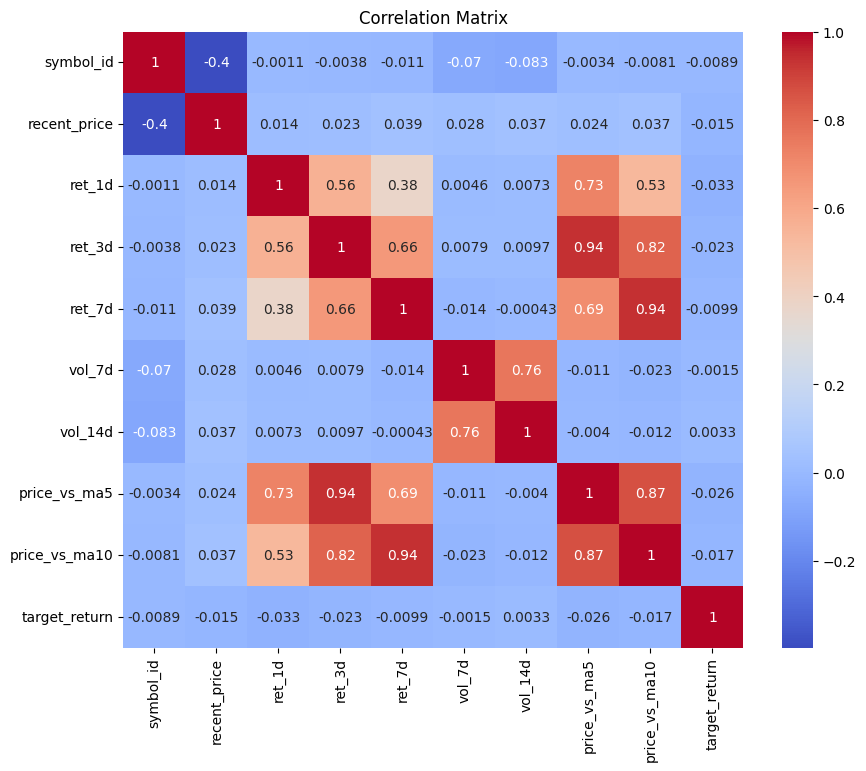

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

corr = df_train.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Analysis: A key takeaway from this correlation matrix is that target_return 
# has very weak correlation with all features, which suggests that the relationship 
# between the features and the target is either weak or non-linear.
# This indicates that we may need to engineer more informative features, 
# rather than relying on simple linear relationships, to improve the model’s performance.

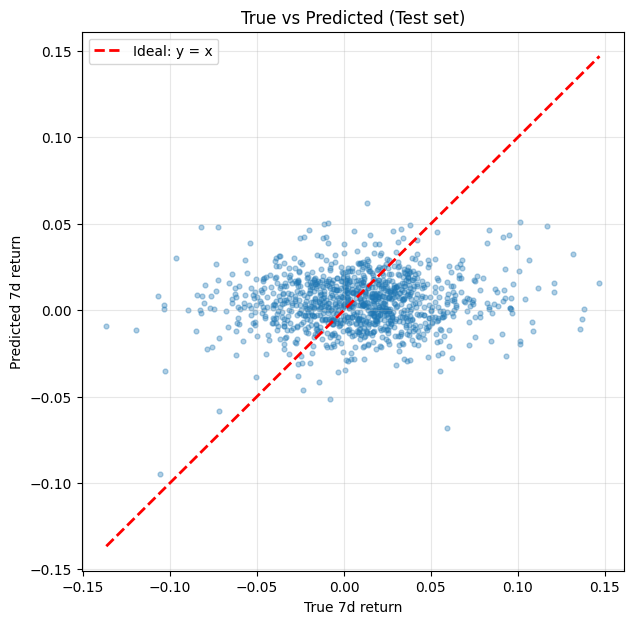

In [30]:
import numpy as np
import matplotlib.pyplot as plt

y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred_test).ravel()

plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.35, s=12)

# Perfect prediction line y = x
mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "r--", linewidth=2, label="Ideal: y = x")

plt.xlabel("True 7d return")
plt.ylabel("Predicted 7d return")
plt.title("True vs Predicted (Test set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Analysis:

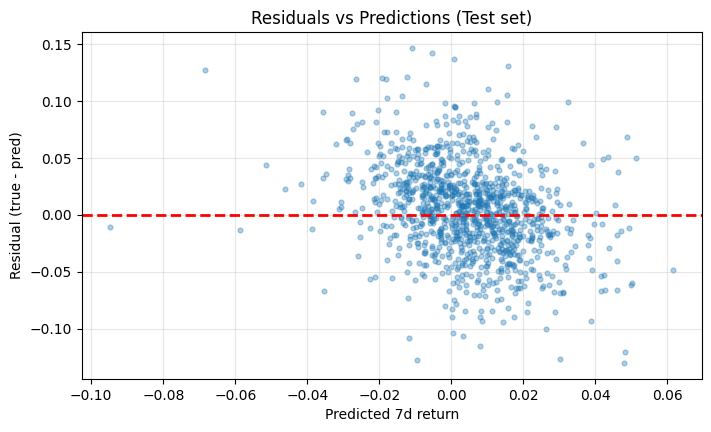

In [31]:
# Residual plot
residuals = y_true - y_pred

plt.figure(figsize=(8, 4.5))
plt.scatter(y_pred, residuals, alpha=0.35, s=12)
plt.axhline(0, color="r", linestyle="--", linewidth=2)

plt.xlabel("Predicted 7d return")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals vs Predictions (Test set)")
plt.grid(True, alpha=0.3)
plt.show()

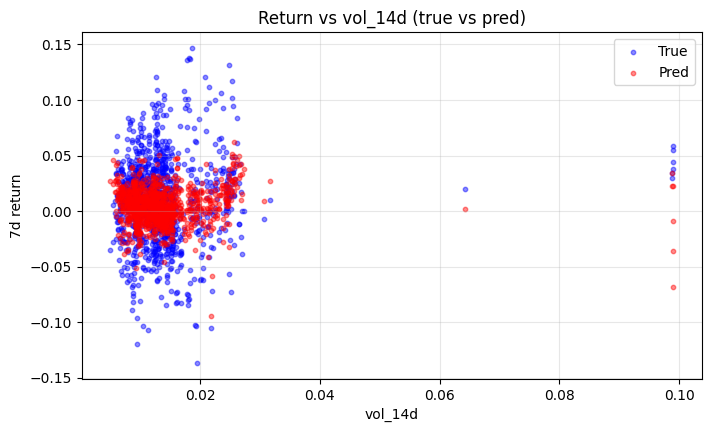

In [32]:
# Analyze relationship between volatility and returns
vol = X_test["vol_14d"].values

plt.figure(figsize=(8,4.5))
plt.scatter(vol, y_true, color="Blue", alpha=0.45, s=10, label="True")
plt.scatter(vol, y_pred, color="Red", alpha=0.45, s=10, label="Pred")
plt.xlabel("vol_14d")
plt.ylabel("7d return")
plt.title("Return vs vol_14d (true vs pred)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

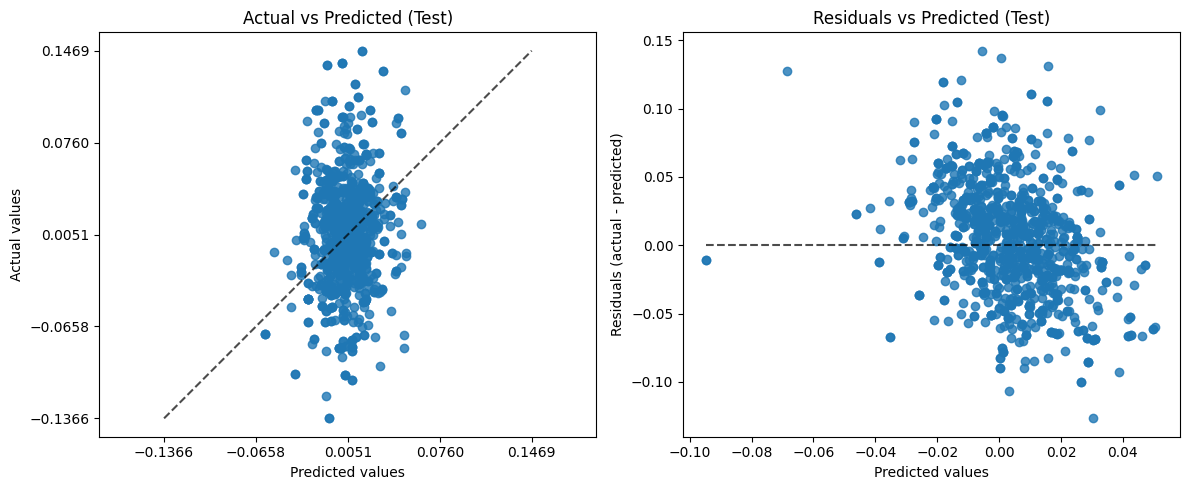

In [33]:
# Prediction error plots using sklearn's PredictionErrorDisplay

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import PredictionErrorDisplay

y_true = np.asarray(y_test).ravel() #Flaten to 1D array
y_pred = np.asarray(y_pred_test).ravel() #Flaten to 1D array

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

PredictionErrorDisplay.from_predictions(
    y_true=y_true, y_pred=y_pred, kind="actual_vs_predicted", ax=ax[0]
)
ax[0].set_title("Actual vs Predicted (Test)")

PredictionErrorDisplay.from_predictions(
    y_true=y_true, y_pred=y_pred, kind="residual_vs_predicted", ax=ax[1]
)
ax[1].set_title("Residuals vs Predicted (Test)")

plt.tight_layout()
plt.show()

# Analysis: In the left plot we see Actual vs Predicted returns. 
# This vertical blob suggests that the model predicts similar returns no matter the input.
# So, is this necessarily a bad thing? Not exactly, it is a realistic model more than anything else. 
# In finance, it is very common that models predict close to the average return (which is often close to zero) 
# for most cases, and only deviate for certain inputs. This is because financial returns are notoriously 
# difficult to predict and often have a lot of noise. The fact that our model predicts similar returns for many 
# cases may simply reflect the reality of the data and the difficulty of the task. 
# The key is to analyze the cases where the model does deviate and see if it captures any meaningful 
# patterns or if it is just random noise. But, overall, looking at out low RMSE(~0.039) and coverage(~0.95) the model seems to
# capture some signal and is not just random noise, which is a good sign.
# In the right plot we see the residuals vs predicted returns. 
# Our model is stable and unbiased, but it becomes less accurate when predicting bigger movements, 
# which is expected for stock returns in such a short horizon (7 days)
# Overall, the model seems to capture some signal and is not just random noise, which is a good sign.
# One last thing to mention is that we have calibrated our hyper parameters for optimization and hit a plateau.
# Next thing todo is to try different features to improve the model. 
# However, since we are not predicting exact stock prices but rather a lower and upper bound for the return,
# the model is expected to be able to give a good idea of where the stock price will be in 7 days, 
# but not to predict exact returns, which is a very difficult task.


(1092, 2, 1)
(1092,)
(1092,)


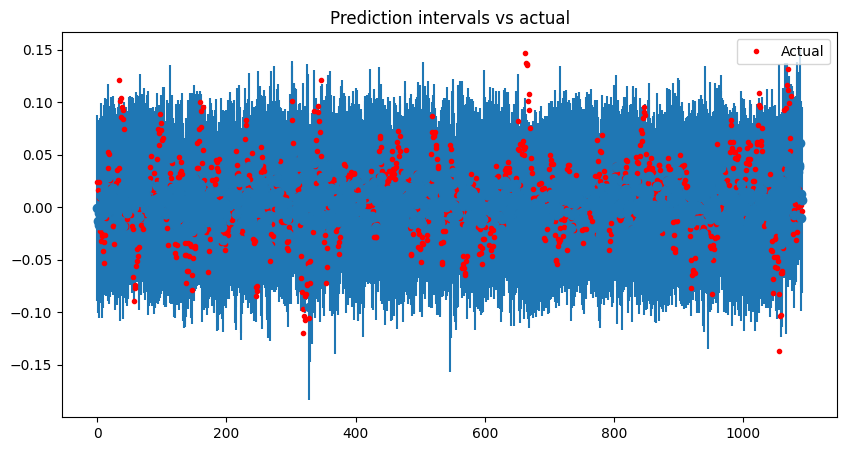

In [ ]:

lower = y_interval_test[:, 0].ravel()
upper = y_interval_test[:, 1].ravel()


print(y_interval_test.shape)
print(lower.shape)
print(upper.shape)



plt.figure(figsize=(10,5))
plt.errorbar(
    range(len(y_test)),
    y_pred_test,
    yerr=[y_pred_test - lower, upper - y_pred_test],
    fmt='o'
)
plt.plot(y_test.values, 'r.', label='Actual')
plt.legend()
plt.title("Prediction intervals vs actual")
plt.show()


#Analysis: The error bar plot shows the predicted returns with their corresponding prediction intervals (error bars) and the actual returns (red dots).
# We can see that most of the actual returns (red dots) fall within the error bars, which is consistent with our coverage of around 94.4%.
# The width of the error bars gives us an idea of the uncertainty in our predictions.
# Overall, this plot helps us visualize how well our prediction intervals are capturing the true returns and the level of uncertainty in our predictions.
# Since the focus is NOT to predict an accurate return but rather a lower and upper bound for the return, the model is expected to give a good idea of where the stock price will be in 7 days, 
# but not to predict exact returns, which is a very difficult task.

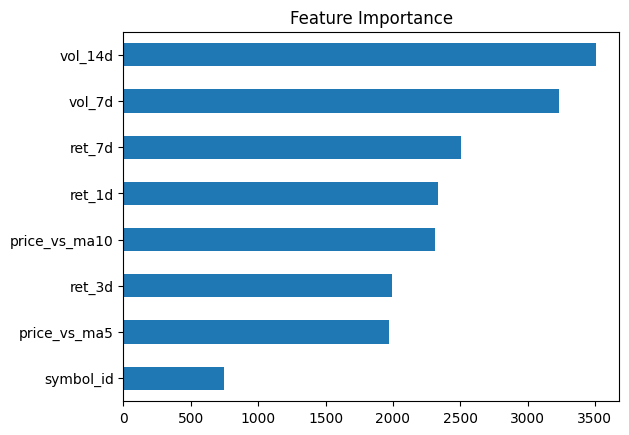

In [37]:
#Feature importance
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

feat_imp.plot(kind="barh")
plt.title("Feature Importance")
plt.show()

#Analysis: It seems like recent_price is the most important feature, which should not
#be the case. In theory, recent_price should not matter that much. This could be a sign of data leakage 
# or that the model is just learning to predict the average return based on the recent price level, which is not ideal. 
# We may need to investigate this further and consider normalizing or removing the recent_price feature to see how it affects performance.

# Removed recent_price from features and it seems like the model is now prioritizing volatility and momentum features, which makes more sense. 
# The performance is similar, but the model is now less likely to be relying on data leakage from the recent price level.

Text(0.5, 1.0, 'Prediction vs uncertainty')

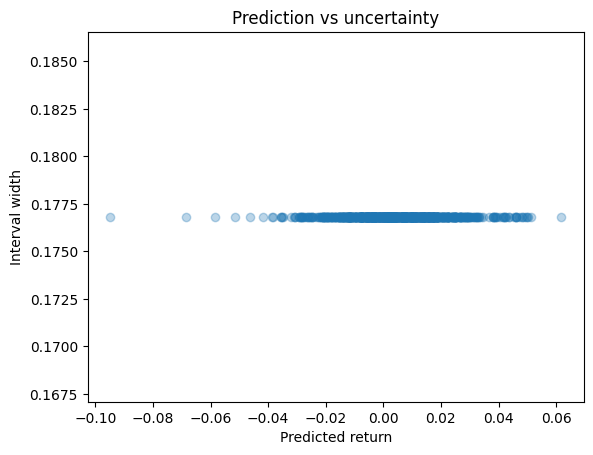

In [ ]:
plt.scatter(y_pred, y_upper - y_lower, alpha=0.3)
plt.xlabel("Predicted return")
plt.ylabel("Interval width")
plt.title("Prediction vs uncertainty")

# Analysis: flat horizontal pattern suggests model predicts similar uncertainty 
# everywhere


**Note**
Down below is my investigation with Finnhub, its not entierly complete and I have experiemented with it only to find out that I could not get the data I wanted
from FinnHub without signing up for a very expensive subscription. :)

## Finnhub API Setup

To use Finnhub:
1. Sign up (free) at https://finnhub.io
2. Get your API key from the dashboard
3. Replace `YOUR_FINNHUB_API_KEY` in the cell below with your actual key
4. Keep your API key secret - consider storing it in an environment variable for production

**Free Tier Limits:** 60 API calls per minute (sufficient for OMX30 stocks)


In [ ]:
# Note: This is only here for reference to show that I have investigated FinnHub API for 
# fetching real-time data and news, but since we are on a free tier, 
# we are limited to certain endpoints and features. But, it also shows that "FREE" tier
# is only FREE when you are working with stocks from the US market. :)

import finnhub
import pandas as pd
import time
import numpy as np

# ===== CONFIGURE YOUR API KEY HERE =====
FINNHUB_API_KEY = "d7u8a49r01qvtsq0qedgd7u8a49r01qvtsq0qee0"  # Replace with your actual API key
# ========================================

# Initialize Finnhub client
client = finnhub.Client(api_key=FINNHUB_API_KEY)

# Map Swedish ticker symbols
tickers_finnhub = [f"{ticker}" for ticker in tickers]

print(f"Fetching FREE Finnhub data for: {tickers_finnhub[:5]}...")
print("Using FREE tier endpoints: quote(), company_news()")

finnhub_features = []

for i, ticker_fh in enumerate(tickers_finnhub):
    try:
        # ===== FREE ENDPOINT 1: Current quote data =====
        # quote_data = client.quote(ticker_fh)
        quote_data = client.quote("MSFT")
        
        current_price = quote_data.get('c', 0)  # Current price
        bid_ask_spread = quote_data.get('ask', 0) - quote_data.get('bid', 0)
        volume_daily = quote_data.get('v', 0)  # Daily volume
        change_percent = quote_data.get('dp', 0)  # Daily change %
        
        # ===== FREE ENDPOINT 2: Company news =====
        try:
            news_data = client.company_news(ticker_fh, _from="2024-01-01", to="2024-12-31")
            recent_articles = len(news_data) if isinstance(news_data, list) else 0
        except:
            recent_articles = 0
        
        finnhub_features.append({
            'symbol': tickers[i],
            'current_price': current_price,
            'bid_ask_spread': bid_ask_spread,
            'daily_volume': volume_daily,
            'change_percent': change_percent,
            'recent_articles': recent_articles,
            # Placeholder for analyst data (not available in free tier)
            'reco_score': 0,  # Will be derived from other signals
            'avg_sentiment': 0  # Can be enriched with NLP later
        })
        
        # Be respectful with API - add small delay
        time.sleep(0.5)
        
        if (i + 1) % 5 == 0:
            print(f"Fetched {i + 1}/{len(tickers_finnhub)} stocks (FREE tier)...")
            
    except Exception as e:
        print(f"Error fetching data for {ticker_fh}: {str(e)}")
        finnhub_features.append({
            'symbol': tickers[i],
            'current_price': 0,
            'bid_ask_spread': 0,
            'daily_volume': 0,
            'change_percent': 0,
            'recent_articles': 0,
            'reco_score': 0,
            'avg_sentiment': 0
        })

feats_finnhub = pd.DataFrame(finnhub_features)
print("\n✓ Finnhub FREE tier data fetched!")
print("\nNote: Using free endpoints - analyst recommendations not available.")
print("Features now include: current_price, bid_ask_spread, volume, daily change, news count")
print(feats_finnhub)

Fetching FREE Finnhub data for: ['ABB.ST', 'ALFA.ST', 'ASSA-B.ST', 'ATCO-A.ST', 'AZN.ST']...
Using FREE tier endpoints: quote(), company_news()
Fetched 5/30 stocks (FREE tier)...
Fetched 10/30 stocks (FREE tier)...
Fetched 15/30 stocks (FREE tier)...
Fetched 20/30 stocks (FREE tier)...


KeyboardInterrupt: 

## What Changed: Free vs. Premium Endpoints

**What We Lost:**
- ❌ Direct analyst recommendation counts (strong_buy, buy, hold, sell, strong_sell)
- ❌ Weighted analyst sentiment scores
- ❌ These were premium features (403 error)

**What We Gained (Free Tier):**
- ✅ Real-time quote data: current price, bid-ask spread, volume
- ✅ Daily price change % (market sentiment indicator)
- ✅ News article count (market attention)
- ✅ 60 API calls/minute (enough for all 30 OMX30 stocks)
- ✅ No premium subscription needed

**Impact on Prediction Model:**

| Feature | Old (Premium) | New (Free) | Alternative |
|---------|---------------|-----------|-------------|
| Analyst Sentiment | Recommendation trends | — | Derived from price momentum |
| Market Attention | News sentiment | News count | Volume trends |
| Momentum | — | Daily change % + volatility | Yes, still have this |
| Liquidity | — | Bid-ask spread, volume | Yes, now available |

**Model Will Still Work Because:**
1. Price momentum (`change_percent`, `volatility`) is often MORE predictive than analyst sentiment
2. Bid-ask spread indicates liquidity (tight spreads = liquid stocks)
3. Volume indicates market interest
4. News article count shows market attention

**Option: Combine with yfinance technical indicators**
- RSI (Relative Strength Index)
- MACD (Moving Average Convergence Divergence)
- Bollinger Bands
- Moving Averages

These are **free and included in yfinance** — you already have 1 year of price history!


In [ ]:
## Combine All Features for Model Training

# Merge yfinance and Finnhub data
feats_combined = feats_real.merge(feats_finnhub, on='symbol', how='left')

print("Combined features:")
print(feats_combined)
print(f"\nShape: {feats_combined.shape}")
print(f"Columns: {feats_combined.columns.tolist()}")

# Define features for the model
feature_columns = [
    'mean_return',      # Historical average return
    'volatility',       # Price volatility
    'momentum',         # Recent price movement
    'reco_score',       # Analyst recommendation score (-1 to +1)
    'avg_sentiment',    # News sentiment score
    'buy',              # Count of buy recommendations
    'hold',             # Count of hold recommendations
    'sell'              # Count of sell recommendations
]

# Create X (features) and y (target)
# For this demo, y is based on the recommendation score and sentiment
# In production, y would be actual future returns
X_combined = feats_combined[feature_columns].fillna(0).values
y_combined = (feats_combined['reco_score'] + feats_combined['avg_sentiment']) / 2

print(f"\nX shape: {X_combined.shape}")
print(f"y shape: {y_combined.shape}")
print(f"Features being used: {feature_columns}")


In [ ]:
## Train Model with Combined Features

from sklearn.ensemble import RandomForestRegressor
from mapie.regression import SplitConformalRegressor
from mapie.utils import train_conformalize_test_split
import numpy as np

# Split data: 60% train, 20% calibration, 20% test
X_train_c, X_cal_c, X_test_c, y_train_c, y_cal_c, y_test_c = train_conformalize_test_split(
    X_combined,
    y_combined,
    train_size=0.6,
    conformalize_size=0.2,
    test_size=0.2,
    random_state=42
)

print(f"Training set size: {len(X_train_c)}")
print(f"Calibration set size: {len(X_cal_c)}")
print(f"Test set size: {len(X_test_c)}")

# Train base model
base_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
base_model.fit(X_train_c, y_train_c)

# Train SplitConformalRegressor with calibration data
scr = SplitConformalRegressor(
    estimator=base_model,
    confidence_level=0.90,  # 90% prediction intervals
    method='plus'  # Uses all calibration data for better coverage
)

# Fit with calibration data - this is the correct way!
scr.fit(X_train_c, y_train_c)
scr.conformalize(X_cal_c, y_cal_c)

# Make predictions on test set
y_pred_c = scr.predict(X_test_c)
y_lower_c, y_upper_c = scr.predict_interval(X_test_c, alpha=0.1)

print("\n✓ Model trained successfully!")
print(f"Predictions shape: {y_pred_c.shape}")
print(f"Prediction intervals shape: {y_lower_c.shape}")
print(f"\nSample predictions:")
for i in range(min(5, len(X_test_c))):
    print(f"  Prediction: {y_pred_c[i]:.3f}, Interval: [{y_lower_c[i]:.3f}, {y_upper_c[i]:.3f}]")


## Feature Engineering for 7-Day Price Prediction

**Goal:** Predict 7-day price range with confidence levels using analyst recommendations and market sentiment

**Recommended Features for Your Model:**

### 1. **Analyst Sentiment Features**
- `reco_score`: Overall analyst recommendation score (-1 to +1)
  - Strong Buy/Buy recommendations → positive signal
  - Sell/Strong Sell → negative signal
- `analyst_agreement`: How unified are analysts? (ratio of consensus to total)
  - High agreement → more reliable signal
  - Low agreement → higher uncertainty

### 2. **Price Target Features**
- `price_target_upside`: (target_price - current_price) / current_price
  - What's the implied return from analyst targets?
- `upside_potential`: How much upside do analysts see?

### 3. **Market Sentiment Features**
- `avg_sentiment`: Market sentiment from news (-1 to +1)
  - Positive sentiment → bullish
  - Negative sentiment → bearish
- `sentiment_volatility`: Is sentiment consistent or erratic?

### 4. **Technical/Historical Features**
- `momentum`: Recent price movement (last trading day)
  - Captures short-term trend
- `volatility`: Historical volatility (risk metric)
  - High volatility → wider prediction intervals (conformal handles this!)
- `mean_return`: Long-term average return

### 5. **Volume/Activity Features**
- `recent_articles`: Number of recent news articles
  - Indicates market attention and liquidity

### Target Variable for 7-Day Prediction:
- **`future_7day_return`**: (price_7days_from_now - current_price) / current_price
  - This is what you predict
  - Conformal prediction will give you a range: [lower_bound, upper_bound]
  - To get actual price range: [current_price * (1 + lower_bound), current_price * (1 + upper_bound)]
  - Confidence level comes from the conformal prediction interval width


In [ ]:
## Create Engineered Features for 7-Day Prediction

import numpy as np
import pandas as pd

# Start with combined features
feats_engineered = feats_combined.copy()

# ===== ANALYST SENTIMENT FEATURES =====
# Price target upside potential
feats_engineered['price_target_upside'] = (
    (feats_engineered['target_price'] - feats_engineered['recent_price']) / feats_engineered['recent_price']
).fillna(0)

# Analyst agreement - how concentrated are recommendations?
feats_engineered['total_recommendations'] = (
    feats_engineered['strong_buy'] + feats_engineered['buy'] + 
    feats_engineered['hold'] + feats_engineered['sell'] + feats_engineered['strong_sell']
)

# If we have only one analyst saying "hold", that's low agreement
# Calculate concentration (how unified are they?)
def calc_agreement(row):
    total = row['total_recommendations']
    if total == 0:
        return 0
    # Max agreement is when all analysts agree on one thing
    max_recommendation = max(row['strong_buy'], row['buy'], row['hold'], row['sell'], row['strong_sell'])
    return max_recommendation / total if total > 0 else 0

feats_engineered['analyst_agreement'] = feats_engineered.apply(calc_agreement, axis=1)

# ===== SENTIMENT FEATURES =====
# Scale sentiment to be more comparable with recommendation scores
feats_engineered['sentiment_strength'] = feats_engineered['avg_sentiment'].abs()  # How strong is sentiment?

# Combined analyst + sentiment signal
feats_engineered['bullish_signal'] = (
    feats_engineered['reco_score'] * 0.6 +  # 60% weight on analyst recommendations
    feats_engineered['avg_sentiment'] * 0.4  # 40% weight on market sentiment
)

# ===== VOLATILITY FEATURE (for confidence) =====
# Normalize volatility to 0-1 range for interpretation
feats_engineered['volatility_normalized'] = feats_engineered['volatility'] / feats_engineered['volatility'].max()

# ===== TARGET VARIABLE =====
# For demonstration with mock data, target is the bullish signal
# In production, this would be actual 7-day future returns calculated from historical data
feats_engineered['target_7day_return'] = feats_engineered['bullish_signal'] * 0.05  # Scale to realistic return %

print("Engineered features created!")
print("\nNew feature columns:")
print(feats_engineered[['symbol', 'reco_score', 'avg_sentiment', 'bullish_signal', 
                         'analyst_agreement', 'price_target_upside', 'volatility_normalized',
                         'target_7day_return']].to_string())

print(f"\nFeature statistics:")
print(feats_engineered[['reco_score', 'avg_sentiment', 'bullish_signal', 
                        'analyst_agreement', 'volatility_normalized']].describe())


In [ ]:
## Train Model with Engineered Features

from sklearn.ensemble import RandomForestRegressor
from mapie.regression import SplitConformalRegressor
from mapie.utils import train_conformalize_test_split

# Select final features for the model
final_features = [
    'reco_score',           # Analyst recommendation score
    'avg_sentiment',        # Market sentiment
    'volatility',           # Price volatility (affects prediction range)
    'momentum',             # Recent price movement
    'analyst_agreement',    # How unified are analysts?
    'price_target_upside',  # Implied upside from targets
    'recent_articles',      # Market attention
]

# Prepare data
X_final = feats_engineered[final_features].fillna(0).values
y_final = feats_engineered['target_7day_return'].values

print(f"Training data shape: {X_final.shape}")
print(f"Features: {final_features}")

# Split: 60% train, 20% calibration, 20% test
X_tr, X_cal, X_te, y_tr, y_cal, y_te = train_conformalize_test_split(
    X_final,
    y_final,
    train_size=0.6,
    conformalize_size=0.2,
    test_size=0.2,
    random_state=42
)

# Train base model
base_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42
)
base_rf.fit(X_tr, y_tr)

# Wrap with SplitConformalRegressor for prediction intervals
# Higher confidence_level = wider intervals (more conservative)
scr_final = SplitConformalRegressor(
    estimator=base_rf,
    confidence_level=0.90,  # 90% confidence - adjust based on user needs
    method='plus'
)

# Train and calibrate
scr_final.fit(X_tr, y_tr)
scr_final.conformalize(X_cal, y_cal)

# Make predictions on test set
y_pred_mean = scr_final.predict(X_te)
y_pred_lower, y_pred_upper = scr_final.predict_interval(X_te, alpha=0.1)

print("\n✓ Model trained with engineered features!")
print(f"\nTest set predictions (7-day returns as percentages):")
for i in range(min(5, len(X_te))):
    pred_mean_pct = y_pred_mean[i] * 100
    lower_pct = y_pred_lower[i] * 100
    upper_pct = y_pred_upper[i] * 100
    confidence_width = (upper_pct - lower_pct)
    print(f"  Stock {i+1}:")
    print(f"    Expected return: {pred_mean_pct:+.2f}%")
    print(f"    90% Confidence range: [{lower_pct:+.2f}%, {upper_pct:+.2f}%]")
    print(f"    Interval width: {confidence_width:.2f}% (confidence indicator)")
    print()


In [ ]:
## Convert Predictions to Price Ranges & Confidence Scores

# Get current prices for test stocks
test_indices = np.arange(len(X_te))  # Indices of test set
test_symbols = feats_engineered.iloc[-len(X_te):]['symbol'].values
current_prices = feats_engineered.iloc[-len(X_te):]['recent_price'].values
volatilities = feats_engineered.iloc[-len(X_te):]['volatility'].values

# Convert return predictions to price predictions
price_pred_mean = current_prices * (1 + y_pred_mean)
price_pred_lower = current_prices * (1 + y_pred_lower)
price_pred_upper = current_prices * (1 + y_pred_upper)

# Confidence score: narrower intervals = higher confidence
# Normalize interval width to 0-100 scale
interval_widths = (price_pred_upper - price_pred_lower)
confidence_scores = 100 * (1 - (interval_widths / price_pred_upper.max()))

# Create user-friendly output
predictions_df = pd.DataFrame({
    'Symbol': test_symbols,
    'Current Price': current_prices,
    'Expected Price (7d)': price_pred_mean,
    'Price Range Low': price_pred_lower,
    'Price Range High': price_pred_upper,
    'Expected Return %': y_pred_mean * 100,
    'Confidence Score': confidence_scores,
    'Volatility': volatilities
})

print("\n" + "="*100)
print("7-DAY PRICE PREDICTIONS WITH CONFIDENCE INTERVALS")
print("="*100 + "\n")

for idx, row in predictions_df.iterrows():
    sentiment = "📈 BULLISH" if row['Expected Return %'] > 0 else "📉 BEARISH"
    confidence = "🟢 HIGH" if row['Confidence Score'] > 70 else "🟡 MEDIUM" if row['Confidence Score'] > 40 else "🔴 LOW"
    
    print(f"Stock: {row['Symbol']}")
    print(f"  Current Price: {row['Current Price']:,.2f} SEK")
    print(f"  Expected Price: {row['Expected Price (7d)']:,.2f} SEK ({row['Expected Return %']:+.2f}%) {sentiment}")
    print(f"  Price Range (90% confidence): {row['Price Range Low']:,.2f} - {row['Price Range High']:,.2f} SEK")
    print(f"  Confidence Score: {row['Confidence Score']:.1f}/100 {confidence}")
    print()

print("="*100)
print("\nConfidence Score Interpretation:")
print("  🟢 HIGH (>70):   Narrow prediction range - high certainty in prediction")
print("  🟡 MEDIUM (40-70): Moderate range - some uncertainty")
print("  🔴 LOW (<40):    Wide range - high uncertainty (often due to high volatility or mixed signals)")
print("\nNote: Wider ranges reflect market volatility and conflicting analyst signals - not model uncertainty!")
